GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Global FEDAVG Rounds:   0%|          | 0/10 [00:00<?, ?it/s]

Round 1/10 → Global acc=0.4853, loss=1.1712
Round 2/10 → Global acc=0.7597, loss=0.6468
Round 3/10 → Global acc=0.8412, loss=0.4584
Round 4/10 → Global acc=0.8624, loss=0.4195
Round 5/10 → Global acc=0.8893, loss=0.3646
Round 6/10 → Global acc=0.8963, loss=0.3558
Round 7/10 → Global acc=0.8997, loss=0.3460
Round 8/10 → Global acc=0.9089, loss=0.3269
Round 9/10 → Global acc=0.9224, loss=0.3039
Round 10/10 → Global acc=0.9215, loss=0.3061
FedAvg model saved.


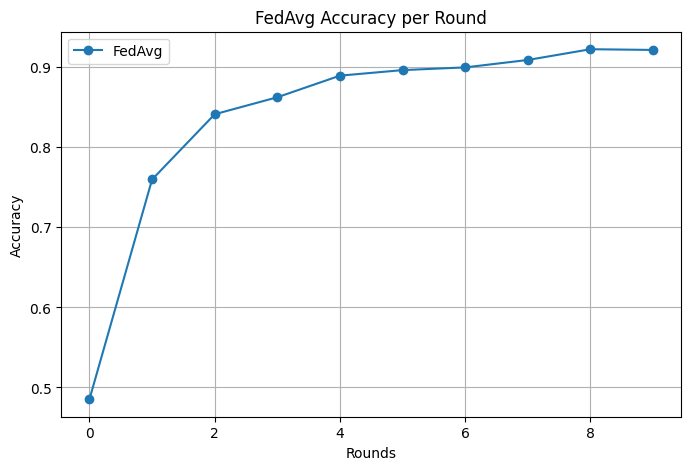

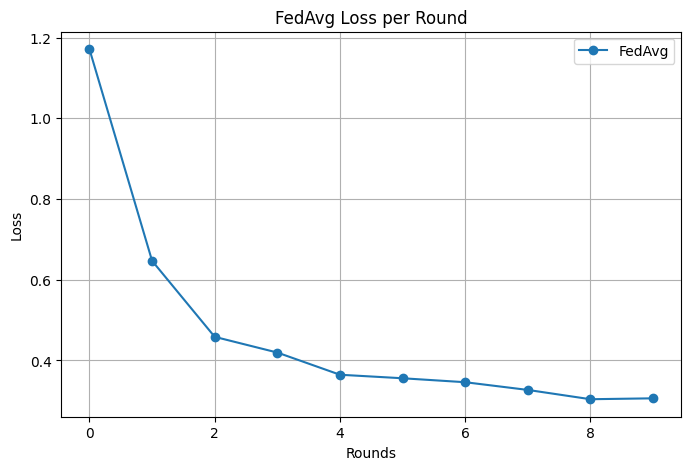

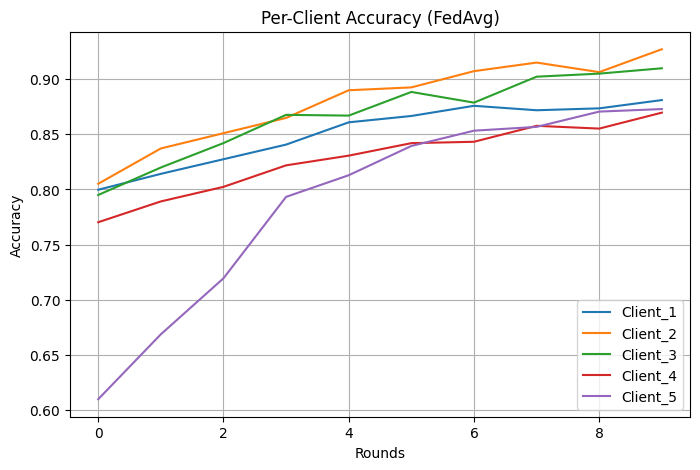

Global FEDNOVA Rounds:   0%|          | 0/10 [00:00<?, ?it/s]

Round 1/10 → Global acc=0.2490, loss=nan
Round 2/10 → Global acc=0.6649, loss=0.9584
Round 3/10 → Global acc=0.8347, loss=0.4728
Round 4/10 → Global acc=0.8712, loss=0.4028
Round 5/10 → Global acc=0.8966, loss=0.3350
Round 6/10 → Global acc=0.9016, loss=0.3393
Round 7/10 → Global acc=0.9053, loss=0.3290
Round 8/10 → Global acc=0.9138, loss=0.3105
Round 9/10 → Global acc=0.9182, loss=0.3121
Round 10/10 → Global acc=0.9207, loss=0.3089
FedNova model saved.


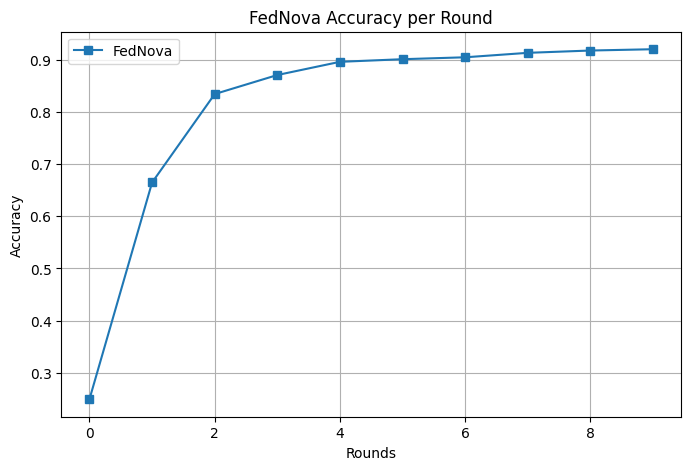

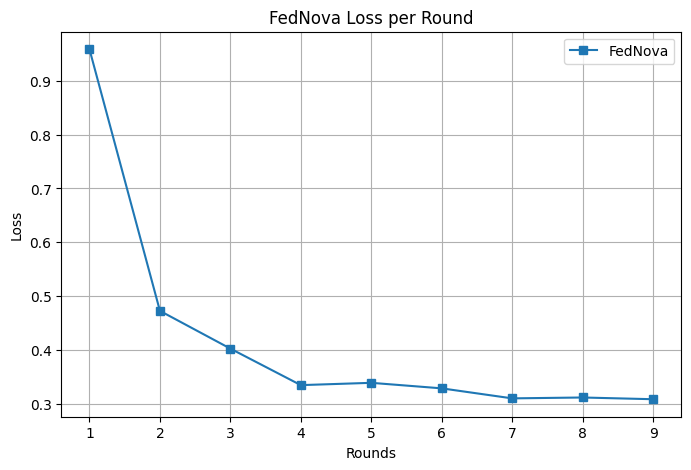

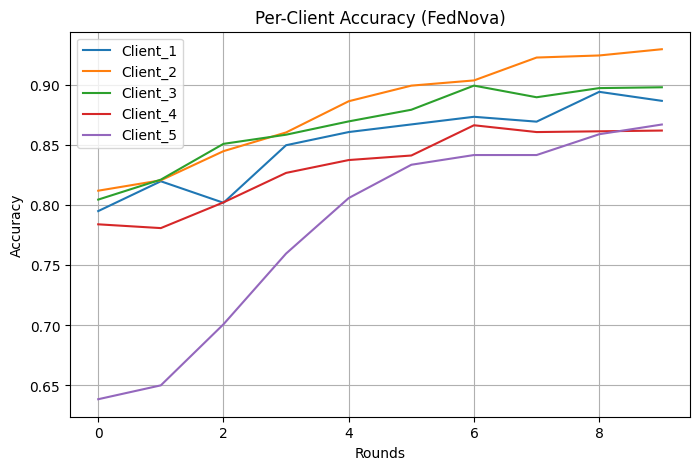

In [ ]:


import os, gc, math, numpy as np, tensorflow as tf
from tensorflow import keras as K
from tensorflow.keras import layers
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# -------------------- 0) CONFIG --------------------
BASE_PATH = ""
CLIENTS   = [f"Client_{i}" for i in range(1, 6)]
QFN       = "quantum_features_realistic.npy"
LFN       = "labels_realistic.npy"
CLASSES   = ["MildDemented","ModerateDemented","NonDemented","VeryMildDemented"]

ROUNDS        = 10
LOCAL_EPOCHS  = 20
BATCH_SIZE    = 32
LR            = 1e-3
SEED          = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)

print("GPUs:", tf.config.list_physical_devices('GPU'))
set_global_policy("mixed_float16")

# -------------------- 1) MODEL --------------------
def make_model(input_dim, num_classes):
    opt = K.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
    m = K.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(1024, kernel_initializer="he_uniform"), layers.LeakyReLU(0.1), layers.BatchNormalization(), layers.Dropout(0.30),
        layers.Dense(512 , kernel_initializer="he_uniform"), layers.LeakyReLU(0.1), layers.BatchNormalization(), layers.Dropout(0.25),
        layers.Dense(256 , kernel_initializer="he_uniform"), layers.LeakyReLU(0.1), layers.BatchNormalization(), layers.Dropout(0.15),
        layers.Dense(128 , kernel_initializer="he_uniform"), layers.LeakyReLU(0.1), layers.BatchNormalization(),
        layers.Dense(len(CLASSES), activation="softmax", dtype="float32")
    ])
    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# -------------------- 2) UTILITIES --------------------
def get_w(m): return m.get_weights()
def set_w(m, w): m.set_weights(w)
def w_sub(a,b): return [x - y for x,y in zip(a,b)]

def aggregate_fedavg(w_global, local_weights, client_sizes):
    N = sum(client_sizes); agg = None
    for w_loc, n_i in zip(local_weights, client_sizes):
        scaled = [p*(n_i/N) for p in w_loc]
        agg = scaled if agg is None else [a+b for a,b in zip(agg, scaled)]
    return agg

def aggregate_fednova(w_global, deltas, local_steps, client_sizes):
    N_total = sum(client_sizes)
    mean_steps = sum(n_i * s_i for n_i, s_i in zip(client_sizes, local_steps)) / N_total
    aggregated_scaled = None
    for d_i, s_i, n_i in zip(deltas, local_steps, client_sizes):
        scaled = [p*(1.0/s_i) for p in d_i]
        weighted_scaled = [p*(n_i/N_total) for p in scaled]
        aggregated_scaled = weighted_scaled if aggregated_scaled is None else [a+b for a,b in zip(aggregated_scaled, weighted_scaled)]
    return [g + mean_steps*u for g,u in zip(w_global, aggregated_scaled)]

def _load_client_arrays(client_dir):
    qpath = os.path.join(client_dir, QFN)
    lpath = os.path.join(client_dir, LFN)
    if not os.path.exists(qpath): qpath = os.path.join(client_dir, "quantum_features.npy")
    if not os.path.exists(lpath): lpath = os.path.join(client_dir, "labels.npy")
    return np.load(qpath, allow_pickle=True), np.load(lpath, allow_pickle=True)

def load_clients():
    data, sizes = {}, []
    for c in CLIENTS:
        X, y = _load_client_arrays(os.path.join(BASE_PATH, c))
        data[c] = (X, y); sizes.append(len(y))
    return data, sizes

def make_ds(X, y, batch=BATCH_SIZE, training=True):
    X = X.astype("float16", copy=False)
    y = y.astype(np.int64,  copy=False)
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training: ds = ds.shuffle(buffer_size=min(len(y), 8192), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# -------------------- 3) TRAIN FUNCTION --------------------
def federated_train(method="fedavg"):
    assert method in ("fedavg","fednova")
    client_data, client_sizes = load_clients()
    sample_dim = next(iter(client_data.values()))[0].shape[1]
    num_classes = len(CLASSES)

    splits = {}
    for c in CLIENTS:
        X, y = client_data[c]
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
        splits[c] = (Xtr, ytr, Xte, yte)

    X_test_all = np.concatenate([splits[c][2] for c in CLIENTS]).astype("float16", copy=False)
    y_test_all = np.concatenate([splits[c][3] for c in CLIENTS])
    ds_test = make_ds(X_test_all, y_test_all, training=False)

    global_model = make_model(sample_dim, num_classes)
    hist_acc, hist_loss = [], []
    per_client_hist = [[] for _ in CLIENTS]

    for r in tqdm(range(ROUNDS), desc=f"Global {method.upper()} Rounds"):
        w_g = get_w(global_model)
        local_weights, deltas, local_steps = [], [], []

        for i, c in enumerate(CLIENTS):
            Xtr, ytr, Xte, yte = splits[c]
            ds_tr = make_ds(Xtr, ytr, training=True)
            ds_te = make_ds(Xte, yte, training=False)

            m = make_model(sample_dim, num_classes)
            set_w(m, w_g)

            steps_per_epoch = math.ceil(len(ytr) / BATCH_SIZE)
            for _ in range(LOCAL_EPOCHS):
                m.fit(ds_tr, epochs=1, verbose=0)

            y_pred_loc = np.argmax(m.predict(ds_te, verbose=0), axis=1)
            per_client_hist[i].append(accuracy_score(yte, y_pred_loc))

            w_l = get_w(m)
            local_weights.append(w_l)
            deltas.append(w_sub(w_l, w_g))
            local_steps.append(LOCAL_EPOCHS * steps_per_epoch)

            del m, ds_tr, ds_te
            K.backend.clear_session()

        if method == "fedavg":
            w_new = aggregate_fedavg(w_g, local_weights, client_sizes)
        else:
            w_new = aggregate_fednova(w_g, deltas, local_steps, client_sizes)

        set_w(global_model, w_new)
        loss, acc = global_model.evaluate(ds_test, verbose=0)
        hist_acc.append(acc); hist_loss.append(loss)
        print(f"Round {r+1}/{ROUNDS} → Global acc={acc:.4f}, loss={loss:.4f}")

        del local_weights, deltas, local_steps
        K.backend.clear_session()

    return {
        "method": method,
        "acc": hist_acc,
        "loss": hist_loss,
        "per_client_hist": per_client_hist,
        "global_model": global_model
    }

# -------------------- 4) FEDAVG FIRST --------------------
out_avg = federated_train("fedavg")

# Save and plot FedAvg
out_avg["global_model"].save(os.path.join(SAVE_DIR, "fedavg_qcnn_model.h5"))
print("FedAvg model saved.")

plt.figure(figsize=(8,5))
plt.plot(out_avg["acc"], label="FedAvg", marker='o')
plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.title("FedAvg Accuracy per Round")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.plot(out_avg["loss"], label="FedAvg", marker='o')
plt.xlabel("Rounds"); plt.ylabel("Loss"); plt.title("FedAvg Loss per Round")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
for i, c in enumerate(CLIENTS):
    plt.plot(out_avg["per_client_hist"][i], label=c)
plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.title("Per-Client Accuracy (FedAvg)")
plt.legend(); plt.grid(True); plt.show()

# Clear memory after FedAvg
del out_avg
gc.collect()
K.backend.clear_session()
tf.compat.v1.reset_default_graph()

# -------------------- 5) FEDNOVA SECOND --------------------
out_nova = federated_train("fednova")

# Save and plot FedNova
out_nova["global_model"].save(os.path.join(SAVE_DIR, "fednova_qcnn_model.h5"))
print("FedNova model saved.")

plt.figure(figsize=(8,5))
plt.plot(out_nova["acc"], label="FedNova", marker='s')
plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.title("FedNova Accuracy per Round")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.plot(out_nova["loss"], label="FedNova", marker='s')
plt.xlabel("Rounds"); plt.ylabel("Loss"); plt.title("FedNova Loss per Round")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
for i, c in enumerate(CLIENTS):
    plt.plot(out_nova["per_client_hist"][i], label=c)
plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.title("Per-Client Accuracy (FedNova)")
plt.legend(); plt.grid(True); plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 93.3 MB/s eta 0:00:00:00:0100:01


Extracting Quantum Features: 100%|██████████| 400/400 [18:58<00:00,  2.85s/it]


Saved test features to /kaggle/working/
Quantum Feature Shape: (400, 4096)

================ FedAvg TEST RESULTS ================
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8861 - loss: 0.5227 
FedAvg Test Accuracy: 0.9050
FedAvg Test Loss: 0.4102
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

Classification Report (FedAvg):
                  precision    recall  f1-score   support

    MildDemented       0.95      0.83      0.89       100
ModerateDemented       0.96      0.98      0.97       100
     NonDemented       0.83      0.96      0.89       100
VeryMildDemented       0.89      0.85      0.87       100

        accuracy                           0.91       400
       macro avg       0.91      0.91      0.90       400
    weighted avg       0.91      0.91      0.90       400



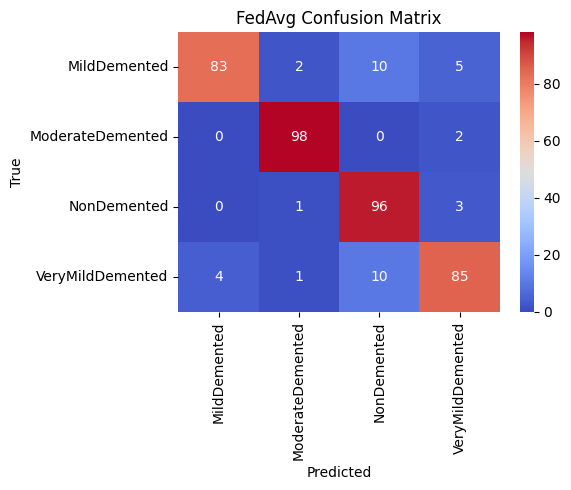


================ FedNova TEST RESULTS ================
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8923 - loss: 0.4629
FedNova Test Accuracy: 0.9025
FedNova Test Loss: 0.4235
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

Classification Report (FedNova):
                  precision    recall  f1-score   support

    MildDemented       0.89      0.86      0.87       100
ModerateDemented       0.95      0.98      0.97       100
     NonDemented       0.85      0.93      0.89       100
VeryMildDemented       0.92      0.84      0.88       100

        accuracy                           0.90       400
       macro avg       0.90      0.90      0.90       400
    weighted avg       0.90      0.90      0.90       400



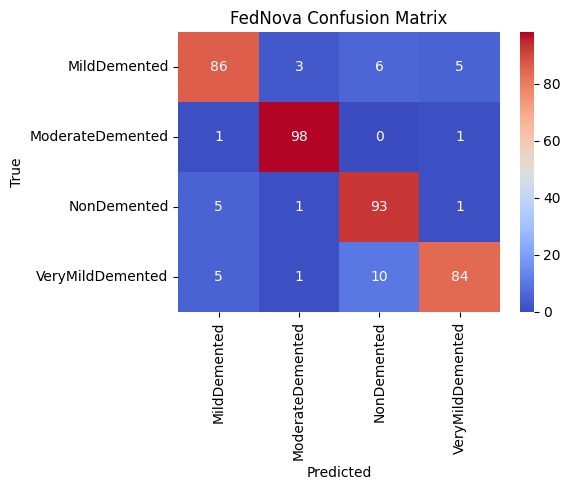

In [3]:
#  IMPORTS 
!pip install pennylane --quiet
import os
import numpy as np
import cv2
from tqdm import tqdm
import pennylane as qml
import tensorflow as tf
from tensorflow import keras as K
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CONFIG 
TEST_PATH = "/kaggle/input/qcnn-vs-cnn/Quantum_features/test"
IMG_SIZE = 64
PATCH_SIZE = 2
WIRES = 4
SAVE_DIR = "/kaggle/working"
QFEATURES_FILE = os.path.join(SAVE_DIR, "q_features_test.npy")
LABELS_FILE = os.path.join(SAVE_DIR, "y_test.npy")
CLASSES_FILE = os.path.join(SAVE_DIR, "class_names.npy")
FEDAVG_MODEL_PATH = os.path.join(SAVE_DIR, "fedavg_qcnn_model.h5")
FEDNOVA_MODEL_PATH = os.path.join(SAVE_DIR, "fednova_qcnn_model.h5")

# QUANTUM CIRCUIT 
dev = qml.device("default.qubit", wires=WIRES)

@qml.qnode(dev)
def quantum_patch_circuit(phi):
    qml.RX(phi[0], wires=0)
    qml.RX(phi[1], wires=1)
    qml.RX(phi[2], wires=2)
    qml.RX(phi[3], wires=3)

    qml.CNOT(wires=[0, 1])
    qml.RZ(np.pi / 2, wires=1)
    qml.CNOT(wires=[0, 1])

    qml.CNOT(wires=[2, 3])
    qml.RZ(np.pi / 2, wires=3)
    qml.CNOT(wires=[2, 3])

    qml.CNOT(wires=[1, 2])
    qml.RZ(np.pi / 2, wires=2)
    qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(i)) for i in range(WIRES)]

def extract_q_features(image, patch_size=PATCH_SIZE):
    h, w = image.shape
    features = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i + patch_size, j:j + patch_size].flatten()
            if patch.shape[0] < WIRES:
                patch = np.concatenate([patch, np.zeros(WIRES - patch.shape[0])])
            features.append(quantum_patch_circuit(patch))
    return np.array(features).flatten()

def load_test_images(path, img_size=64):
    images, labels = [], []
    classes = sorted(os.listdir(path))
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    for cls in classes:
        cls_folder = os.path.join(path, cls)
        for file in tqdm(os.listdir(cls_folder), desc=f"Loading {cls}", leave=False):
            fp = os.path.join(cls_folder, file)
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size)) / 255.0
            images.append(img)
            labels.append(class_to_idx[cls])
    return np.array(images), np.array(labels), classes

#  LOAD OR EXTRACT TEST FEATURES 
if os.path.exists(QFEATURES_FILE) and os.path.exists(LABELS_FILE) and os.path.exists(CLASSES_FILE):
    q_features_test = np.load(QFEATURES_FILE)
    y_test = np.load(LABELS_FILE)
    class_names = np.load(CLASSES_FILE, allow_pickle=True)
    print("Found cached quantum test features; skipping extraction.")
else:
    X_test_imgs, y_test, class_names = load_test_images(TEST_PATH, IMG_SIZE)
    q_features_test = []
    for img in tqdm(X_test_imgs, desc="Extracting Quantum Features"):
        q_features_test.append(extract_q_features(img))
    q_features_test = np.array(q_features_test)
    np.save(QFEATURES_FILE, q_features_test)
    np.save(LABELS_FILE, y_test)
    np.save(CLASSES_FILE, class_names)
    print("Saved test features to /kaggle/working/")

print(f"Quantum Feature Shape: {q_features_test.shape}")

# LOAD TRAINED MODELS 
if not os.path.exists(FEDAVG_MODEL_PATH) or not os.path.exists(FEDNOVA_MODEL_PATH):
    raise FileNotFoundError("Saved models not found in /kaggle/working/. Run training cell first to create fedavg_qcnn_model.h5 and fednova_qcnn_model.h5")

fedavg_model = K.models.load_model(FEDAVG_MODEL_PATH)
fednova_model = K.models.load_model(FEDNOVA_MODEL_PATH)

# EVALUATION FUNCTION
def evaluate_model(model, X, y, title):
    print(f"\n================ {title} TEST RESULTS ================")
    test_loss, test_acc = model.evaluate(X, y, verbose=1)
    print(f"{title} Test Accuracy: {test_acc:.4f}")
    print(f"{title} Test Loss: {test_loss:.4f}")

    y_pred = np.argmax(model.predict(X), axis=1)

    print(f"\nClassification Report ({title}):")
    print(classification_report(y, y_pred, target_names=class_names))

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# RUN TESTS
evaluate_model(fedavg_model, q_features_test, y_test, "FedAvg")
evaluate_model(fednova_model, q_features_test, y_test, "FedNova")
